# Notebook 05. Historical refit with event-time decomposition

Phase 2 deliverable: fit xSSVI to every trading day in the SPY 2010-2023 corpus, decompose the ATM total variance term structure into a diffusive baseline plus FOMC and CPI event premia, and persist a year-partitioned history for downstream analysis.

Event handling: instead of excluding event-spanning expiries, the observed ATM total variance is decomposed via NNLS into

$$\theta_{\text{market}}(T) \approx v_{\text{typical}}^2 \cdot T + n_{\text{FOMC}}(T) \cdot \sigma^2_{\text{FOMC}} + n_{\text{CPI}}(T) \cdot \sigma^2_{\text{CPI}}$$

where $n_{\text{TYPE}}(T)$ is the number of TYPE events in the option's life. The xSSVI smile fit runs on all expiries with no exclusion. Reference: Bergomi, *Stochastic Volatility Modeling*, ch. 6 (forward variance decomposition); Derman-Kani-Kamal (1996) variance time scaling.

In [1]:
# ----------------------------------------------------------------
# 0. Setup and imports
# ----------------------------------------------------------------
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception:
    pass

import sys
sys.path.insert(0, '/content/drive/MyDrive/Vol_fitter')

import json
import time
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from dataclasses import asdict
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

from volsurf.paths import (PROJECT_ROOT, RAW_DIR, LOCAL_RAW,
                            PROCESSED_DIR, FITTED_DIR, AUX_DIR)
from volsurf.data import load_optionsdx_year
from volsurf.rates import load_treasury_curve, get_rate
from volsurf.pricing import deamericanise_snapshot_fast
from volsurf.parametric_ssvi import (SSVIParams, build_atm_theta_curve,
                                      fit_ssvi_surface, fit_xssvi_surface,
                                      xssvi_w, XSSVISurface)

RAW_DIR_FAST = LOCAL_RAW if LOCAL_RAW.exists() else RAW_DIR
treasury = load_treasury_curve()

print(f'Raw data:     {RAW_DIR_FAST}')
print(f'Treasury:     {len(treasury):,} rows loaded')
print(f'Processed:    {PROCESSED_DIR}')
print(f'Fitted:       {FITTED_DIR}')


Mounted at /content/drive
Raw data:     /content/drive/MyDrive/Vol_fitter/data_SPY
Treasury:     47,124 rows loaded
Processed:    /content/drive/MyDrive/Vol_fitter/data_processed
Fitted:       /content/drive/MyDrive/Vol_fitter/data_fitted


In [2]:
# ----------------------------------------------------------------
# 1. Output directory structure
# ----------------------------------------------------------------
# Year-partitioned xSSVI history plus sidecar dirs for logs and run manifests.

XSSVI_HISTORY_DIR = FITTED_DIR / 'xssvi_history'
XSSVI_LOGS_DIR = XSSVI_HISTORY_DIR / '_logs'
XSSVI_RUNS_DIR = XSSVI_HISTORY_DIR / '_runs'

for d in [XSSVI_HISTORY_DIR, XSSVI_LOGS_DIR, XSSVI_RUNS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'History root: {XSSVI_HISTORY_DIR}')
print(f'Logs dir:     {XSSVI_LOGS_DIR}')
print(f'Runs dir:     {XSSVI_RUNS_DIR}')


History root: /content/drive/MyDrive/Vol_fitter/data_fitted/xssvi_history
Logs dir:     /content/drive/MyDrive/Vol_fitter/data_fitted/xssvi_history/_logs
Runs dir:     /content/drive/MyDrive/Vol_fitter/data_fitted/xssvi_history/_runs


In [3]:
# ----------------------------------------------------------------
# 2. Discovery: what's available, what's already done
# ----------------------------------------------------------------
# Quick inventory before the batch. Years present, trading days per year,
# how many snapshots are already de-Americanised from previous notebooks.

YEARS = list(range(2010, 2024))

year_rows = []
for year in YEARS:
    try:
        df_y = load_optionsdx_year(year, raw_dir=RAW_DIR_FAST)
        year_rows.append({'year': year, 'rows': len(df_y),
                          'trading_days': int(df_y.QUOTE_DATE.nunique())})
    except FileNotFoundError:
        year_rows.append({'year': year, 'rows': 0, 'trading_days': 0})

year_df = pd.DataFrame(year_rows)
print('Raw corpus:')
print(year_df.to_string(index=False))
print(f'  Total trading days: {year_df.trading_days.sum():,}')

processed = sorted(PROCESSED_DIR.glob('chain_*.parquet'))
existing_history = sorted(XSSVI_HISTORY_DIR.glob('year=*/part.parquet'))
print(f'\nProcessed de-Am snapshots already on disk: {len(processed)}')
if processed:
    print(f'  Examples: {[p.stem for p in processed[:3]]}')
print(f'xSSVI history partitions already present:  {len(existing_history)}')


Raw corpus:
 year    rows  trading_days
 2010  262978           250
 2011  285265           245
 2012  340926           250
 2013  361258           252
 2014  421454           250
 2015  492643           252
 2016  544085           251
 2017  609530           250
 2018  755129           252
 2019  834075           248
 2020 1164401           250
 2021 1277698           252
 2022 1146980           256
 2023  972162           250
  Total trading days: 3,508

Processed de-Am snapshots already on disk: 3500
  Examples: ['chain_2010-01-04', 'chain_2010-01-05', 'chain_2010-01-06']
xSSVI history partitions already present:  14


## Event calendar

FOMC statement dates 2010-2023 are hardcoded from Fed historical records. CPI release dates are approximated as the 12th of each month, rolled forward to the next weekday. Both can be overridden by dropping a CSV under `AUX_DIR/fomc_dates.csv` or `AUX_DIR/cpi_dates.csv`.

In [4]:
# ----------------------------------------------------------------
# 3. FOMC calendar (2010-2023, statement-release day)
# ----------------------------------------------------------------
# Hardcoded from Federal Reserve historical calendars. For two-day meetings
# we use the second (statement-release) day, which is when the IV jump
# happens. Editable: if any date is off, drop a corrected CSV under
# AUX_DIR/fomc_dates.csv and the loader below picks it up.

_FOMC_DATES_HARDCODED = [
    # 2010
    '2010-01-27', '2010-03-16', '2010-04-28', '2010-06-23',
    '2010-08-10', '2010-09-21', '2010-11-03', '2010-12-14',
    # 2011
    '2011-01-26', '2011-03-15', '2011-04-27', '2011-06-22',
    '2011-08-09', '2011-09-21', '2011-11-02', '2011-12-13',
    # 2012
    '2012-01-25', '2012-03-13', '2012-04-25', '2012-06-20',
    '2012-08-01', '2012-09-13', '2012-10-24', '2012-12-12',
    # 2013
    '2013-01-30', '2013-03-20', '2013-05-01', '2013-06-19',
    '2013-07-31', '2013-09-18', '2013-10-30', '2013-12-18',
    # 2014
    '2014-01-29', '2014-03-19', '2014-04-30', '2014-06-18',
    '2014-07-30', '2014-09-17', '2014-10-29', '2014-12-17',
    # 2015
    '2015-01-28', '2015-03-18', '2015-04-29', '2015-06-17',
    '2015-07-29', '2015-09-17', '2015-10-28', '2015-12-16',
    # 2016
    '2016-01-27', '2016-03-16', '2016-04-27', '2016-06-15',
    '2016-07-27', '2016-09-21', '2016-11-02', '2016-12-14',
    # 2017
    '2017-02-01', '2017-03-15', '2017-05-03', '2017-06-14',
    '2017-07-26', '2017-09-20', '2017-11-01', '2017-12-13',
    # 2018
    '2018-01-31', '2018-03-21', '2018-05-02', '2018-06-13',
    '2018-08-01', '2018-09-26', '2018-11-08', '2018-12-19',
    # 2019
    '2019-01-30', '2019-03-20', '2019-05-01', '2019-06-19',
    '2019-07-31', '2019-09-18', '2019-10-30', '2019-12-11',
    # 2020 (includes emergency meetings)
    '2020-01-29', '2020-03-03', '2020-03-15', '2020-04-29',
    '2020-06-10', '2020-07-29', '2020-09-16', '2020-11-05',
    '2020-12-16',
    # 2021
    '2021-01-27', '2021-03-17', '2021-04-28', '2021-06-16',
    '2021-07-28', '2021-09-22', '2021-11-03', '2021-12-15',
    # 2022
    '2022-01-26', '2022-03-16', '2022-05-04', '2022-06-15',
    '2022-07-27', '2022-09-21', '2022-11-02', '2022-12-14',
    # 2023
    '2023-02-01', '2023-03-22', '2023-05-03', '2023-06-14',
    '2023-07-26', '2023-09-20', '2023-11-01', '2023-12-13',
]

_FOMC_OVERRIDE = AUX_DIR / 'fomc_dates.csv'
if _FOMC_OVERRIDE.exists():
    fomc_df = pd.read_csv(_FOMC_OVERRIDE, parse_dates=['date'])
    print(f'Loaded FOMC dates from override CSV: {len(fomc_df)} dates')
else:
    fomc_df = pd.DataFrame({'date': pd.to_datetime(_FOMC_DATES_HARDCODED)})
    print(f'Using hardcoded FOMC dates: {len(fomc_df)} dates')

fomc_df['event_type'] = 'FOMC'
print(f'  Range: {fomc_df.date.min().date()} to {fomc_df.date.max().date()}')
print(f'  Per year:')
print(fomc_df.groupby(fomc_df.date.dt.year).size().to_string())


Using hardcoded FOMC dates: 113 dates
  Range: 2010-01-27 to 2023-12-13
  Per year:
date
2010    8
2011    8
2012    8
2013    8
2014    8
2015    8
2016    8
2017    8
2018    8
2019    8
2020    9
2021    8
2022    8
2023    8


In [5]:
# ----------------------------------------------------------------
# 4. CPI calendar (2010-2023, approximate release dates)
# ----------------------------------------------------------------
# BLS releases CPI roughly the second week of each month, typical day
# the 10th to 14th. We approximate with the 12th, rolling forward to
# the next weekday if the 12th is a weekend. ~12 events per year.
# Editable: drop AUX_DIR/cpi_dates.csv to override with exact BLS dates.

_CPI_OVERRIDE = AUX_DIR / 'cpi_dates.csv'
if _CPI_OVERRIDE.exists():
    cpi_df = pd.read_csv(_CPI_OVERRIDE, parse_dates=['date'])
    print(f'Loaded CPI dates from override CSV: {len(cpi_df)} dates')
else:
    months = pd.date_range('2010-01-01', '2023-12-31', freq='MS')
    cpi_dates = []
    for m in months:
        d = m + pd.Timedelta(days=11)  # the 12th
        while d.weekday() >= 5:  # Sat=5, Sun=6
            d += pd.Timedelta(days=1)
        cpi_dates.append(d)
    cpi_df = pd.DataFrame({'date': cpi_dates})
    print(f'Using approximate CPI dates (12th of month, weekday-adjusted): {len(cpi_df)} dates')

cpi_df['event_type'] = 'CPI'
print(f'  Range: {cpi_df.date.min().date()} to {cpi_df.date.max().date()}')
print(f'  Per year: median {int(cpi_df.groupby(cpi_df.date.dt.year).size().median())}')


Using approximate CPI dates (12th of month, weekday-adjusted): 168 dates
  Range: 2010-01-12 to 2023-12-12
  Per year: median 12


In [6]:
# ----------------------------------------------------------------
# 5. Combined event calendar, persisted
# ----------------------------------------------------------------
events = pd.concat([fomc_df, cpi_df], ignore_index=True).sort_values('date').reset_index(drop=True)
events['date'] = pd.to_datetime(events['date'])

events_path = AUX_DIR / 'event_calendar.parquet'
events.to_parquet(events_path)
print(f'Persisted: {events_path}')
print(f'  Total events: {len(events):,}')
print(f'  FOMC: {(events.event_type == "FOMC").sum()}')
print(f'  CPI:  {(events.event_type == "CPI").sum()}')
print(f'  Range: {events.date.min().date()} to {events.date.max().date()}')

# Sanity: how often do FOMC and CPI fall on the same day?
clash = events.groupby('date').size()
multi = clash[clash > 1]
print(f'\n  Days with multiple events: {len(multi)}')
if len(multi) > 0:
    print(f'  Example: {multi.head(3).to_dict()}')


Persisted: /content/drive/MyDrive/Vol_fitter/data_raw_aux/event_calendar.parquet
  Total events: 281
  FOMC: 113
  CPI:  168
  Range: 2010-01-12 to 2023-12-13

  Days with multiple events: 1
  Example: {Timestamp('2012-12-12 00:00:00'): 2}


In [7]:
# ----------------------------------------------------------------
# 6. Event-spanning diagnostic (descriptive only, not used in fit)
# ----------------------------------------------------------------
# Helper for inspecting which scheduled events sit inside a given option's life.
# The fit itself uses n_FOMC_to_expiry / n_CPI_to_expiry counts produced in the
# pipeline; this is a convenience for ad-hoc poking.

def flag_expiry(quote_date, expiry, events_df):
    D = pd.Timestamp(quote_date); E = pd.Timestamp(expiry)
    matching = events_df[(events_df.date > D) & (events_df.date <= E)]
    return (bool(len(matching)), int(len(matching)),
            ';'.join(sorted(matching.event_type.unique())) if len(matching) else '')

f, c, t = flag_expiry(pd.Timestamp('2010-06-15'), pd.Timestamp('2010-07-30'), events)
print(f'2010-06-15 -> 2010-07-30: {c} events ({t})')


2010-06-15 -> 2010-07-30: 2 events (CPI;FOMC)


## Per-date pipeline

Runs de-Americanisation (or loads cached), builds the snap dataframe, fits xSSVI on all expiries, decomposes the ATM curve into diffusive + event variances, and emits one row per (date, expiry) with both model state and decomposition parameters.

In [8]:
# ----------------------------------------------------------------
# 7. Per-date pipeline (event-time decomposition)
# ----------------------------------------------------------------
# Industry-standard form: every expiry goes into the xSSVI fit (no exclusion).
# Event premia are estimated by decomposing the observed ATM total variance
# curve into a diffusive base plus per-event-type contributions, via NNLS:
#
#   theta_market(T_i) ~= v_typical_sq * T_i
#                         + n_FOMC(T_i) * variance_FOMC
#                         + n_CPI(T_i)  * variance_CPI
#
# where n_TYPE(T_i) is the count of TYPE events in (D, D + T_i]. The fitted
# variance_TYPE values are the event premia priced by the surface at date D.
#
# References: Bergomi, Stochastic Volatility Modeling (ch. 6 forward variance
# decomposition); Derman-Kani-Kamal (1996) variance time scaling.

from scipy.optimize import nnls

MIN_STRIKES = 10
SNAP_K_RANGE = (-0.5, 0.3)
SNAP_IV_RANGE = (0.05, 2.0)
TAU_MIN = 0.02
MIN_EXPIRIES = 4


def _build_snap(chain):
    snap = chain.rename(columns={'T': 'tau'}).copy()
    snap['w'] = snap.iv_mid ** 2 * snap.tau
    snap = snap[snap.iv_mid.between(*SNAP_IV_RANGE) & snap.k.between(*SNAP_K_RANGE)]
    snap = snap[snap.tau > TAU_MIN].reset_index(drop=True)
    return snap


def _count_events_to(date, expiry, events_df, event_type):
    D = pd.Timestamp(date); E = pd.Timestamp(expiry)
    return int(((events_df.date > D) & (events_df.date <= E) &
                (events_df.event_type == event_type)).sum())


def decompose_event_variance(date, atm_curve, events_df):
    """NNLS decomposition of theta_market into diffusive + event premia.

    Returns dict with v_typical_sq, variance_FOMC, variance_CPI, residual
    (mean abs in vol points), rank, n_obs.
    """
    D = pd.Timestamp(date)
    Ts = atm_curve['T'].values
    thetas = atm_curve['theta_raw'].values
    n_fomc = np.array([_count_events_to(D, D + pd.Timedelta(days=int(round(t * 365))),
                                          events_df, 'FOMC') for t in Ts])
    n_cpi = np.array([_count_events_to(D, D + pd.Timedelta(days=int(round(t * 365))),
                                         events_df, 'CPI') for t in Ts])
    # Design: [T, n_FOMC, n_CPI]. Non-negativity on all three.
    A = np.column_stack([Ts, n_fomc, n_cpi])
    keep = np.isfinite(thetas) & (thetas > 0)
    if keep.sum() < 3:
        return {'v_typical_sq': np.nan, 'variance_FOMC': np.nan,
                'variance_CPI': np.nan, 'residual_vp': np.nan,
                'rank': 0, 'n_obs': int(keep.sum())}
    coef, _ = nnls(A[keep], thetas[keep])
    fitted = A[keep] @ coef
    # Convert residual back to vol-pt scale via local linearisation: dsigma ~= dtheta / (2 sigma T)
    sigmas = np.sqrt(thetas[keep] / Ts[keep])
    resid_vp = float(np.mean(np.abs((fitted - thetas[keep]) / (2 * sigmas * Ts[keep]))) * 100)
    rank = int(np.linalg.matrix_rank(A[keep]))
    return {
        'v_typical_sq': float(coef[0]), 'variance_FOMC': float(coef[1]),
        'variance_CPI': float(coef[2]), 'residual_vp': resid_vp,
        'rank': rank, 'n_obs': int(keep.sum()),
    }


def _slice_rmse_iv(slice_df, T, theta_e, rho_e, eta, gamma):
    if len(slice_df) == 0:
        return np.nan
    w_model = xssvi_w(slice_df.k.values, theta_e, rho_e, eta, gamma)
    iv_model = np.sqrt(np.clip(w_model, 1e-10, None) / T)
    return float(np.sqrt(np.mean((iv_model - slice_df.iv_mid.values) ** 2)))


def process_date(date, df_year, treasury_df, events_df,
                 prev_ssvi_init=None, verbose=False):
    """Full pipeline for one trading date. Returns (rows, status)."""
    date = pd.Timestamp(date)
    status = {
        'date': date, 'fit_status': 'pending', 'fit_iterations': 0,
        'n_expiries': 0, 'fail_reason': None, 'elapsed_s': 0.0,
    }
    t0 = time.time()

    # 1. de-Am (or load cached)
    chain_path = PROCESSED_DIR / f'chain_{date.date()}.parquet'
    if chain_path.exists():
        chain = pd.read_parquet(chain_path)
    else:
        chain, _ = deamericanise_snapshot_fast(date, df_year, treasury_df,
                                                min_strikes=MIN_STRIKES)
        if chain is None or len(chain) == 0:
            status.update(fit_status='fail_deam', fail_reason='de-Am produced no rows',
                          elapsed_s=time.time() - t0)
            return [], status
        chain.to_parquet(chain_path)

    # 2. snap
    snap = _build_snap(chain)
    if snap.expiry.nunique() < MIN_EXPIRIES:
        status.update(fit_status='fail_insufficient_data',
                      fail_reason=f'only {snap.expiry.nunique()} expiries',
                      elapsed_s=time.time() - t0)
        return [], status

    # 3. ATM term structure (market signal, no exclusion)
    atm = build_atm_theta_curve(snap)

    # 4. xSSVI fit on ALL expiries
    if prev_ssvi_init is None:
        ssvi_p, _ = fit_ssvi_surface(snap, atm, weights='vega')
        warm = ssvi_p
    else:
        warm = prev_ssvi_init

    try:
        xssvi = fit_xssvi_surface(snap, atm, ssvi_init=warm, weights='vega')
    except Exception as exc:
        status.update(fit_status='fail_xssvi', fail_reason=str(exc),
                      elapsed_s=time.time() - t0)
        return [], status

    if not xssvi['result'].success:
        try:
            ssvi_cold, _ = fit_ssvi_surface(snap, atm, weights='vega')
            xssvi_retry = fit_xssvi_surface(snap, atm, ssvi_init=ssvi_cold,
                                             weights='vega')
            if xssvi_retry['result'].success or xssvi_retry['result'].fun < xssvi['result'].fun:
                xssvi = xssvi_retry
        except Exception:
            pass

    surface = XSSVISurface(xssvi, S=float(snap.S.iloc[0]), snapshot_date=date)

    # 5. Event-variance decomposition (NNLS on theta_market vs [T, n_FOMC, n_CPI])
    decomp = decompose_event_variance(date, atm, events_df)

    # 6. Expiry -> position in xssvi state
    expiry_to_idx = {e: i for i, e in enumerate(xssvi['expiries'])}

    # 7. one row per expiry
    rows = []
    for _, atm_row in atm.iterrows():
        expiry = atm_row.expiry
        T_e = float(atm_row['T'])
        theta_T_market = float(atm_row.theta_raw) if atm_row.theta_raw > 0 else np.nan
        atm_iv_market = float(np.sqrt(theta_T_market / T_e)) if np.isfinite(theta_T_market) else np.nan

        slice_df = snap[snap.expiry == expiry]
        chain_e = chain[chain.expiry == expiry].iloc[0]

        rho_T_model = float(surface.rho(T_e))
        atm_skew = float(surface.atm_skew(T_e))

        idx = expiry_to_idx.get(expiry)
        if idx is not None:
            rmse_iv = _slice_rmse_iv(slice_df, T_e, xssvi['thetas'][idx],
                                      xssvi['rhos'][idx], xssvi['eta'], xssvi['gamma'])
            theta_e_fit = float(xssvi['thetas'][idx])
        else:
            rmse_iv = np.nan
            theta_e_fit = np.nan

        # Event counts to this expiry
        n_fomc_e = _count_events_to(date, expiry, events_df, 'FOMC')
        n_cpi_e = _count_events_to(date, expiry, events_df, 'CPI')
        diffusive_theta_e = decomp['v_typical_sq'] * T_e
        event_theta_e = (n_fomc_e * decomp['variance_FOMC']
                          + n_cpi_e * decomp['variance_CPI'])

        rows.append({
            'date': date, 'expiry': expiry, 'T': T_e,
            'forward': float(chain_e.F), 'spot': float(chain_e.S),
            'r': float(chain_e.r), 'q': float(chain_e.q),
            'xssvi_eta': float(xssvi['eta']),
            'xssvi_gamma': float(xssvi['gamma']),
            'xssvi_rho_t': rho_T_model,
            'theta_T_market': theta_T_market,
            'theta_T_fit': theta_e_fit,
            'atm_iv': atm_iv_market,
            'atm_skew': atm_skew,
            'n_quotes': int(len(slice_df)),
            'fit_rmse_iv': rmse_iv,
            'fit_rmse_iv_oos': np.nan,
            # Event decomposition (date-level, replicated per row)
            'v_typical_sq': decomp['v_typical_sq'],
            'variance_FOMC': decomp['variance_FOMC'],
            'variance_CPI': decomp['variance_CPI'],
            'decomp_residual_vp': decomp['residual_vp'],
            'decomp_rank': decomp['rank'],
            # Per-expiry event counts
            'n_FOMC_to_expiry': n_fomc_e,
            'n_CPI_to_expiry': n_cpi_e,
            'diffusive_theta_to_expiry': diffusive_theta_e,
            'event_theta_to_expiry': event_theta_e,
            'fit_status': 'success' if xssvi['result'].success else 'partial',
            'fit_iterations': int(xssvi['result'].nit),
        })

    status.update(
        fit_status='success' if xssvi['result'].success else 'partial',
        fit_iterations=int(xssvi['result'].nit),
        n_expiries=int(snap.expiry.nunique()),
        elapsed_s=time.time() - t0,
    )
    status['_xssvi_state'] = xssvi
    return rows, status


def warm_start_from(prev_xssvi_state):
    return SSVIParams(
        rho=float(np.mean(prev_xssvi_state['rhos'])),
        eta=float(prev_xssvi_state['eta']),
        gamma=float(prev_xssvi_state['gamma']),
    )

print('Pipeline defined.')


Pipeline defined.


In [9]:
# ----------------------------------------------------------------
# 7b. Bugfix: empty-day handling and defensive exception capture
# ----------------------------------------------------------------
# Some OptionsDX dates contain rows with all-NaN price columns (eight such
# days in 2010 alone, e.g. 2010-01-27 to 2010-02-05). The upstream de-Am
# function drops them via the bid/ask filter and then crashes on .iloc[0].
# We patch the call site here to return cleanly instead, and also wrap
# process_date in a top-level try/except so any other surprise downstream
# logs a fail row rather than killing the whole batch.

_inner_deam_fast = deamericanise_snapshot_fast

def deamericanise_snapshot_fast(date, df, treasury_df, min_strikes=10, verbose=False):
    """Early-return when the liquidity filter empties the day."""
    day = df[df.QUOTE_DATE == pd.Timestamp(date)]
    liquid = day[(day.C_BID > 0) & (day.C_ASK > day.C_BID) &
                  (day.P_BID > 0) & (day.P_ASK > day.P_BID)]
    if liquid.empty:
        diag = pd.DataFrame([{'fail_reason': 'no liquid quotes after bid/ask filter',
                              'n_strikes_filtered': 0, 'n_raw_rows': len(day)}])
        return pd.DataFrame(), diag
    return _inner_deam_fast(date, df, treasury_df, min_strikes=min_strikes,
                             verbose=verbose)


_inner_process_date = process_date

def process_date(date, df_year, treasury_df, events_df,
                 prev_ssvi_init=None, verbose=False):
    """Defensive wrapper: any unexpected exception gets logged as fail_exception."""
    try:
        return _inner_process_date(date, df_year, treasury_df, events_df,
                                    prev_ssvi_init=prev_ssvi_init, verbose=verbose)
    except Exception as exc:
        return [], {
            'date': pd.Timestamp(date),
            'fit_status': 'fail_exception',
            'fit_iterations': 0,
            'n_expiries': 0,
            'fail_reason': f'{type(exc).__name__}: {exc}',
            'elapsed_s': 0.0,
        }

print('Patched: empty-day de-Am and defensive process_date exception capture.')

Patched: empty-day de-Am and defensive process_date exception capture.


In [10]:
# ----------------------------------------------------------------
# 7c. Performance: vectorised BS2002 inversion across strikes
# ----------------------------------------------------------------
# Replaces the per-strike Newton loop in deamericanise_slice_fast with one
# vectorised Newton step against the full strike array. Roughly 6-7x faster
# on de-Am, validated to machine epsilon (max diff 2e-14) against the scalar
# pricer over a 78-point synthetic grid and against the scalar inverter on
# real 2010-06-15 quotes.

import volsurf.pricing as _vp
from volsurf.pricing import bs_price, bs_vega, bs2002_implied_vol, _phi_bs2002


def _bs2002_call_vec(S, K_in, T, r, q, sigma_in):
    """BS2002 call across array K and array sigma. S, T, r, q scalar."""
    K = np.asarray(K_in, dtype=float)
    sigma = np.asarray(sigma_in, dtype=float)
    shape = np.broadcast_shapes(K.shape, sigma.shape)
    K = np.broadcast_to(K, shape).astype(float, copy=True)
    sigma = np.broadcast_to(sigma, shape).astype(float, copy=True)

    if T <= 0:
        return np.maximum(S - K, 0.0)

    intrinsic = np.maximum(S - K, 0.0)
    bsm = bs_price(S, K, T, r, q, sigma, is_call=True)

    b = r - q
    if b >= r:
        return bsm

    bad_sigma = (sigma <= 0)
    sigma2 = sigma * sigma
    with np.errstate(divide='ignore', invalid='ignore'):
        b_s2 = b / sigma2
        beta = (0.5 - b_s2) + np.sqrt((b_s2 - 0.5) ** 2 + 2.0 * r / sigma2)
    bad_beta = ~np.isfinite(beta) | (beta > 100)

    with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
        B_inf = K * beta / (beta - 1.0)
        B_0 = np.maximum(K, K * r / (r - b))
        h_T = -(b * T + 2.0 * sigma * np.sqrt(T)) * (K * K) / ((B_inf - B_0) * B_0)
        X = B_0 + (B_inf - B_0) * (1.0 - np.exp(h_T))

    immediate = (S >= X)

    with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
        alpha = (X - K) * X ** (-beta)
        main = (alpha * S ** beta
                 - alpha * _phi_bs2002(S, T, beta, X, X, r, q, sigma)
                 + _phi_bs2002(S, T, 1.0, X, X, r, q, sigma)
                 - _phi_bs2002(S, T, 1.0, K, X, r, q, sigma)
                 - K * _phi_bs2002(S, T, 0.0, X, X, r, q, sigma)
                 + K * _phi_bs2002(S, T, 0.0, K, X, r, q, sigma))
    bad_main = ~np.isfinite(main)

    out = np.where(immediate, S - K, main)
    out = np.where(bad_beta | bad_main, bsm, out)
    out = np.where(bad_sigma, intrinsic, out)
    return out


def _bs2002_put_vec(S, K_in, T, r, q, sigma_in):
    """BS2002 put via swapped frame: put(S,K,r,q) = call(K,S,q,r) but with
    K array, so we inline the call formula with S/K roles swapped."""
    K = np.asarray(K_in, dtype=float)
    sigma = np.asarray(sigma_in, dtype=float)
    shape = np.broadcast_shapes(K.shape, sigma.shape)
    K = np.broadcast_to(K, shape).astype(float, copy=True)
    sigma = np.broadcast_to(sigma, shape).astype(float, copy=True)

    S_sw, K_sw, r_sw, q_sw = K, S, q, r

    if T <= 0:
        return np.maximum(K_sw - S_sw, 0.0)

    intrinsic = np.maximum(K_sw - S_sw, 0.0)
    bsm = bs_price(S, K, T, r, q, sigma, is_call=False)

    b = r_sw - q_sw
    if b >= r_sw:
        return bsm

    bad_sigma = (sigma <= 0)
    sigma2 = sigma * sigma
    with np.errstate(divide='ignore', invalid='ignore'):
        b_s2 = b / sigma2
        beta = (0.5 - b_s2) + np.sqrt((b_s2 - 0.5) ** 2 + 2.0 * r_sw / sigma2)
    bad_beta = ~np.isfinite(beta) | (beta > 100)

    with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
        B_inf = K_sw * beta / (beta - 1.0)
        B_0 = np.maximum(K_sw, K_sw * r_sw / (r_sw - b))
        h_T = -(b * T + 2.0 * sigma * np.sqrt(T)) * (K_sw ** 2) / ((B_inf - B_0) * B_0)
        X = B_0 + (B_inf - B_0) * (1.0 - np.exp(h_T))

    immediate = (S_sw >= X)

    with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
        alpha = (X - K_sw) * X ** (-beta)
        main = (alpha * S_sw ** beta
                 - alpha * _phi_bs2002(S_sw, T, beta, X, X, r_sw, q_sw, sigma)
                 + _phi_bs2002(S_sw, T, 1.0, X, X, r_sw, q_sw, sigma)
                 - _phi_bs2002(S_sw, T, 1.0, K_sw, X, r_sw, q_sw, sigma)
                 - K_sw * _phi_bs2002(S_sw, T, 0.0, X, X, r_sw, q_sw, sigma)
                 + K_sw * _phi_bs2002(S_sw, T, 0.0, K_sw, X, r_sw, q_sw, sigma))
    bad_main = ~np.isfinite(main)

    out = np.where(immediate, S_sw - K_sw, main)
    out = np.where(bad_beta | bad_main, bsm, out)
    out = np.where(bad_sigma, intrinsic, out)
    return out


def bs2002_implied_vol_fast_vec(prices, S, K_arr, T, r, q, sigma_init_arr,
                                  is_call=True, n_newton=8, tol=1e-7,
                                  use_brent_fallback=True):
    """Vectorised Newton-Raphson BS2002 IV inversion across strikes."""
    K_arr = np.asarray(K_arr, dtype=float)
    prices = np.asarray(prices, dtype=float)
    sigma_init_arr = np.asarray(sigma_init_arr, dtype=float)
    n = len(K_arr)

    intrinsic = np.maximum(0.0, (S - K_arr) if is_call else (K_arr - S))
    below_intrinsic = prices < intrinsic - 1e-8

    sigma = np.where(np.isfinite(sigma_init_arr) & (sigma_init_arr > 0.01) & (sigma_init_arr < 3.0),
                      sigma_init_arr, 0.20)
    converged = np.zeros(n, dtype=bool)
    stuck = below_intrinsic.copy()

    pricer = _bs2002_call_vec if is_call else _bs2002_put_vec

    for step in range(n_newton):
        active = ~converged & ~stuck
        if not active.any():
            break
        f = pricer(S, K_arr, T, r, q, sigma) - prices
        converged |= (active & (np.abs(f) < tol))
        v = bs_vega(S, K_arr, T, r, q, sigma)
        low_vega = v < 1e-6
        with np.errstate(divide='ignore', invalid='ignore'):
            delta = f / np.where(low_vega, np.nan, v)
            sigma_new = sigma - delta
        in_bounds = (sigma_new > 0.01) & (sigma_new < 5.0) & np.isfinite(sigma_new)
        tiny = np.isfinite(sigma_new) & (np.abs(sigma_new - sigma) < 1e-10)
        update = active & in_bounds & ~low_vega & ~converged
        sigma = np.where(update, sigma_new, sigma)
        converged |= (active & tiny & in_bounds & ~low_vega)
        stuck |= (active & (low_vega | (~in_bounds & ~converged)))

    result = np.where(converged, sigma, np.nan)

    if use_brent_fallback:
        not_done = ~converged & ~below_intrinsic
        for i in np.where(not_done)[0]:
            try:
                result[i] = bs2002_implied_vol(float(prices[i]), S, float(K_arr[i]),
                                                 T, r, q, is_call=is_call)
            except Exception:
                result[i] = np.nan

    return result


def _deamericanise_slice_fast_vec(strikes, c_mid, p_mid, c_iv_seed, p_iv_seed,
                                    S, T, r, q_init=0.015, q_tol=0.0005,
                                    max_iter=4, q_cap=0.10, diag=None):
    """Vectorised drop-in for volsurf.pricing.deamericanise_slice_fast."""
    from scipy.stats import linregress
    strikes = np.asarray(strikes, dtype=float)
    c_mid = np.asarray(c_mid, dtype=float)
    p_mid = np.asarray(p_mid, dtype=float)
    c_iv_seed = np.asarray(c_iv_seed, dtype=float)
    p_iv_seed = np.asarray(p_iv_seed, dtype=float)
    q = q_init
    q_implied = q_init

    for iteration in range(1, max_iter + 1):
        iv_call = bs2002_implied_vol_fast_vec(c_mid, S, strikes, T, r, q, c_iv_seed,
                                                is_call=True)
        iv_put = bs2002_implied_vol_fast_vec(p_mid, S, strikes, T, r, q, p_iv_seed,
                                               is_call=False)
        valid = ~(np.isnan(iv_call) | np.isnan(iv_put))
        if diag is not None:
            diag['n_invert_valid'] = int(valid.sum())
        if valid.sum() < 5:
            if diag is not None:
                diag['fail_reason'] = f'only {valid.sum()} inversions'
            return None
        K_v = strikes[valid]
        C_E = bs_price(S, K_v, T, r, q, iv_call[valid], is_call=True)
        P_E = bs_price(S, K_v, T, r, q, iv_put[valid], is_call=False)
        slope, intercept, *_ = linregress(K_v, C_E - P_E)
        D = -slope
        if D <= 0 or D > 1.5:
            if diag is not None: diag['fail_reason'] = f'bad D: {D:.4f}'
            return None
        F = intercept / D
        if F < 0.3 * S or F > 3.0 * S:
            if diag is not None: diag['fail_reason'] = f'bad F: {F:.2f}'
            return None
        q_implied = -np.log(F / (S * np.exp(r * T))) / T
        q_new = float(np.clip(q_implied, 0.0, q_cap))
        if abs(q_new - q) < q_tol:
            q = q_new
            break
        q = q_new

    k = np.log(strikes / F)
    iv_mid = np.where(k >= 0, iv_call, iv_put)
    return {
        'strike': strikes, 'k': k,
        'iv_call': iv_call, 'iv_put': iv_put, 'iv_mid': iv_mid,
        'F': F, 'q': q, 'q_implied': q_implied, 'D': D,
        'n_iter': iteration, 'n_valid': int(valid.sum()),
    }


_vp.deamericanise_slice_fast = _deamericanise_slice_fast_vec
print('Patched: vectorised BS2002 inversion in deamericanise_slice_fast.')
print('  Locally measured 6-7x speedup on 2010-06-15, parity to machine epsilon.')

Patched: vectorised BS2002 inversion in deamericanise_slice_fast.
  Locally measured 6-7x speedup on 2010-06-15, parity to machine epsilon.


## Pre-batch validation

Eleven stratified dates spanning stress events, the corpus first day, event-mechanic edge cases, and stratified random samples across years. All cold-started so failures are visible. Run before the full batch.

In [11]:
# ----------------------------------------------------------------
# 8. Pre-batch validation on 11 stratified dates
# ----------------------------------------------------------------
# Sanity pass before the full corpus. Mix of stress, sparse-data, event-mechanic
# and stratified-random dates. Each is processed cold (no warm start). We tally
# success/failure, elapsed time, and headline parameters.

VALIDATION_DATES = [
    # Stress
    ('2010-05-06', 'stress: flash crash'),
    ('2018-02-05', 'stress: volpocalypse'),
    ('2020-03-16', 'stress: COVID -12% day'),
    # Sparse data
    ('2010-01-04', 'sparse: corpus first day'),
    # Event mechanic (date sits one day before a scheduled event)
    ('2014-12-16', 'event mechanic: day before FOMC 2014-12-17'),
    ('2017-09-13', 'event mechanic: day before CPI ~14th'),
    # Stratified random across years
    ('2011-07-20', 'random: mid-2011'),
    ('2013-09-05', 'random: mid-2013'),
    ('2015-11-12', 'random: late-2015'),
    ('2019-06-20', 'random: mid-2019'),
    ('2022-04-19', 'random: post-hike-start'),
]

print(f'Validation pass: {len(VALIDATION_DATES)} dates')
print(f'{"Date":>12} {"Year":>6} {"Status":>10} {"N_exp":>6} {"Iter":>5} '
      f'{"sigT%":>7} {"varF":>8} {"varC":>8} {"resid":>7} {"elapsed":>9} Label')

val_results = []
for date_str, label in VALIDATION_DATES:
    date = pd.Timestamp(date_str)
    year = date.year
    try:
        df_year = load_optionsdx_year(year, raw_dir=RAW_DIR_FAST)
    except FileNotFoundError:
        print(f'{date_str:>12} {year:>6} {"NO_DATA":>10}  -- year file missing --  {label}')
        val_results.append({'date': date, 'status': 'no_data', 'label': label})
        continue

    rows, status = process_date(date, df_year, treasury, events, prev_ssvi_init=None)
    if rows:
        row0 = rows[0]
        sig_typ = float(np.sqrt(row0['v_typical_sq'])) if row0['v_typical_sq'] > 0 else 0.0
        print(f'{date_str:>12} {year:>6} {status["fit_status"]:>10} {status["n_expiries"]:>6} '
              f'{status["fit_iterations"]:>5} {sig_typ*100:>6.1f}% '
              f'{row0["variance_FOMC"]:>8.4f} {row0["variance_CPI"]:>8.4f} '
              f'{row0["decomp_residual_vp"]:>6.2f}vp {status["elapsed_s"]:>8.1f}s  {label}')
    else:
        print(f'{date_str:>12} {year:>6} {status["fit_status"]:>10} '
              f'-- {status["fail_reason"]} -- {status["elapsed_s"]:>5.1f}s  {label}')
    val_results.append({'date': date, 'status': status['fit_status'],
                        'n_rows': len(rows), 'label': label,
                        'elapsed_s': status['elapsed_s']})

print(f'\nSummary: {sum(1 for r in val_results if r["status"] == "success")}/{len(val_results)} successful')


Validation pass: 11 dates
        Date   Year     Status  N_exp  Iter   sigT%     varF     varC   resid   elapsed Label
  2010-05-06   2010    success     13     2   19.4%   0.0031   0.0011   0.87vp      1.1s  stress: flash crash
  2018-02-05   2018    success     27     7    0.0%   0.0000   0.0028   2.34vp      2.0s  stress: volpocalypse
  2020-03-16   2020    partial     33     7   34.7%   0.0000   0.0000  21.86vp      3.4s  stress: COVID -12% day
  2010-01-04   2010    success     13     3    0.0%   0.0035   0.0018   2.81vp      0.9s  sparse: corpus first day
  2014-12-16   2014    success     20    35   15.4%   0.0000   0.0015   1.19vp      1.3s  event mechanic: day before FOMC 2014-12-17
  2017-09-13   2017    success     23    35    0.0%   0.0000   0.0018   3.09vp      2.3s  event mechanic: day before CPI ~14th
  2011-07-20   2011    success     16    25    0.0%   0.0000   0.0037   1.81vp      1.1s  random: mid-2011
  2013-09-05   2013    success     18    28   18.3%   0.0000   0

## Year-partitioned batch

Final output layout:

```
data_fitted/xssvi_history/
  year=2010/part.parquet
  year=2011/part.parquet
  ...
  year=2023/part.parquet
  _logs/year_YYYY.csv     per-date status log
  _runs/run_*.json        run manifest
```

Each year is independently resumable. `batch_year` writes a `_partial.parquet` checkpoint every 25 successful fits, so an interrupted Colab session loses at most ~25 dates of work. The warm-start chain (`SSVIParams` carried across consecutive successful fits) resets on failure and at year boundaries.

In [12]:
# ----------------------------------------------------------------
# 9. Year-partitioned batch runner (I fear colab disconnecting randomly)
# ----------------------------------------------------------------
# Processes all trading days in one year. Maintains warm-start chain across
# consecutive successful fits, cold-starts after a failure. Writes a partial
# checkpoint after every successful date so an interrupted run resumes with
# at most one date of lost work. Checkpoint writes are atomic (tmp + rename)
# to survive mid-write disconnects on the Drive FUSE mount. On resume, the
# warm-start SSVIParams are reconstructed from the last completed date's
# fitted parameters so the warm chain continues unbroken.
#
# Layout:
#   FITTED_DIR / xssvi_history / year=YYYY / part.parquet      (final)
#   FITTED_DIR / xssvi_history / year=YYYY / _partial.parquet  (in-progress)
#   FITTED_DIR / xssvi_history / _logs / year_YYYY.csv         (per-date log)

def _year_paths(year):
    yr_dir = XSSVI_HISTORY_DIR / f'year={year}'
    yr_dir.mkdir(parents=True, exist_ok=True)
    return {
        'dir': yr_dir,
        'final': yr_dir / 'part.parquet',
        'partial': yr_dir / '_partial.parquet',
        'log': XSSVI_LOGS_DIR / f'year_{year}.csv',
    }


def _atomic_write_parquet(df, target):
    """Write parquet atomically: full write to .tmp, then rename."""
    tmp = target.with_suffix(target.suffix + '.tmp')
    df.to_parquet(tmp)
    tmp.replace(target)  # atomic on POSIX, near-atomic on Drive FUSE


def _warm_start_from_partial(partial_df):
    """Reconstruct SSVIParams from the last date's fitted rows."""
    last_date = partial_df.date.max()
    last_day = partial_df[partial_df.date == last_date]
    if last_day.empty or last_day.xssvi_rho_t.isna().all():
        return None
    return SSVIParams(
        rho=float(last_day.xssvi_rho_t.mean()),
        eta=float(last_day.xssvi_eta.iloc[0]),
        gamma=float(last_day.xssvi_gamma.iloc[0]),
    )


def batch_year(year, treasury_df, events_df, verbose=True):
    """Process all trading days for one year. Resumable per-date."""
    paths = _year_paths(year)

    if paths['final'].exists():
        existing = pd.read_parquet(paths['final'])
        if verbose:
            print(f'Year {year}: final file already present '
                  f'({len(existing):,} rows, {existing.date.nunique()} dates) - skipping')
        return existing

    df_year = load_optionsdx_year(year, raw_dir=RAW_DIR_FAST)
    all_dates = sorted(df_year.QUOTE_DATE.dt.normalize().unique())

    accumulated_rows = []
    dates_done = set()
    prev_ssvi_init = None

    if paths['partial'].exists():
        try:
            partial = pd.read_parquet(paths['partial'])
            accumulated_rows = partial.to_dict('records')
            dates_done = set(pd.Timestamp(d) for d in partial.date.unique())
            prev_ssvi_init = _warm_start_from_partial(partial)
            if verbose:
                ws_msg = ('warm-start reconstructed' if prev_ssvi_init
                          else 'cold-start (warm reconstruction failed)')
                print(f'Year {year}: resuming, {len(dates_done)} dates already done, {ws_msg}')
        except Exception as exc:
            if verbose:
                print(f'Year {year}: partial file unreadable ({exc}), restarting fresh')
            accumulated_rows = []
            dates_done = set()
            prev_ssvi_init = None

    log_rows = []
    if paths['log'].exists():
        try:
            log_rows = pd.read_csv(paths['log']).to_dict('records')
        except Exception:
            log_rows = []

    t_year_start = time.time()
    n_success = sum(1 for r in log_rows if r.get('fit_status') in ('success', 'partial'))
    n_fail = sum(1 for r in log_rows if r.get('fit_status', '').startswith('fail'))
    last_log_print = time.time()

    for date in all_dates:
        if pd.Timestamp(date) in dates_done:
            continue
        rows, status = process_date(date, df_year, treasury_df, events_df,
                                     prev_ssvi_init=prev_ssvi_init)
        log_rows.append({
            'date': status['date'], 'fit_status': status['fit_status'],
            'n_expiries': status.get('n_expiries', 0),
            'fit_iterations': status['fit_iterations'],
            'fail_reason': status['fail_reason'],
            'elapsed_s': status['elapsed_s'],
        })

        if rows:
            accumulated_rows.extend(rows)
            n_success += 1
            prev_ssvi_init = warm_start_from(status['_xssvi_state'])
            # Per-date atomic checkpoint
            _atomic_write_parquet(pd.DataFrame(accumulated_rows), paths['partial'])
            pd.DataFrame(log_rows).to_csv(paths['log'], index=False)
        else:
            n_fail += 1
            prev_ssvi_init = None  # break warm chain after a failure

        if verbose and time.time() - last_log_print > 30:
            done = n_success + n_fail
            pct = 100 * done / len(all_dates)
            eta = (time.time() - t_year_start) / max(done - len(dates_done), 1) \
                   * (len(all_dates) - done) / 60
            print(f'  {year}: {done}/{len(all_dates)} ({pct:.0f}%) - '
                  f'{n_success} ok, {n_fail} fail - ETA {eta:.0f} min')
            last_log_print = time.time()

    # Finalise: atomic move from partial to final
    if accumulated_rows:
        final_df = pd.DataFrame(accumulated_rows).sort_values(['date', 'T']).reset_index(drop=True)
        _atomic_write_parquet(final_df, paths['final'])
        if paths['partial'].exists():
            paths['partial'].unlink()
    else:
        final_df = pd.DataFrame()

    pd.DataFrame(log_rows).to_csv(paths['log'], index=False)
    elapsed_min = (time.time() - t_year_start) / 60
    if verbose:
        print(f'Year {year} done: {len(final_df):,} rows from {n_success} dates '
              f'({n_fail} failures), {elapsed_min:.1f} min total')
    return final_df

print('Batch runner defined (per-date checkpoint, atomic writes, warm-start resume).')

Batch runner defined (per-date checkpoint, atomic writes, warm-start resume).


In [13]:
# ----------------------------------------------------------------
# 10. Full historical batch orchestrator
# ----------------------------------------------------------------
# Calls batch_year() for every year in the corpus. Each year is independent;
# warm-start chain resets at year boundaries (acceptable since the diffusive
# baseline drifts across years anyway).
#
# Comment out years you don't want to (re)process. To run a single year
# interactively for debugging, just call batch_year(year, treasury, events).

def run_full_batch(years, treasury_df, events_df, verbose=True):
    summaries = []
    for year in years:
        if verbose:
            print(f'\n=== Year {year} ===')
        try:
            df_year = batch_year(year, treasury_df, events_df, verbose=verbose)
            summaries.append({'year': year, 'rows': len(df_year),
                              'dates': int(df_year.date.nunique()) if len(df_year) else 0,
                              'status': 'ok'})
        except Exception as exc:
            summaries.append({'year': year, 'rows': 0, 'dates': 0,
                              'status': f'error: {exc}'})
            if verbose:
                print(f'Year {year} FAILED: {exc}')
    summary_df = pd.DataFrame(summaries)
    if verbose:
        print('\n=== Full batch summary ===')
        print(summary_df.to_string(index=False))
    return summary_df

# To execute, uncomment:
# run_full_batch(YEARS, treasury, events)
print('Full batch orchestrator defined. Call run_full_batch(YEARS, treasury, events) to run.')


Full batch orchestrator defined. Call run_full_batch(YEARS, treasury, events) to run.


## Out-of-sample d+5 pass

Second iteration over the fitted history. For each (date, expiry) with fitted parameters, evaluate the same xSSVI surface against market quotes 5 trading days later. Writes `fit_rmse_iv_oos` back into each year file in place. Measures stability of the calibrated surface.

In [14]:
# ----------------------------------------------------------------
# 11. d+5 OOS pass
# ----------------------------------------------------------------
# For each fitted (date, expiry), evaluate the same xSSVI parameters against
# the market quotes 5 trading days later. Measures surface stability.
#
# Method: take fitted (theta_T_fit, rho_T) from date D for expiry E. Look up
# E's quotes in D+5's processed chain. Predicted IV is
#   sqrt(xssvi_w(k_at_D+5, theta_T_fit, rho_T, eta, gamma) / T_at_D+5)
# RMSE vs D+5's iv_mid -> written back to fit_rmse_iv_oos.

OOS_HORIZON_TDAYS = 5


def _load_chain(date):
    p = PROCESSED_DIR / f'chain_{pd.Timestamp(date).date()}.parquet'
    return pd.read_parquet(p) if p.exists() else None


def oos_year(year, lookahead_year=None, verbose=True):
    """Compute d+5 OOS RMSE for every fitted (date, expiry) in this year."""
    paths = _year_paths(year)
    if not paths['final'].exists():
        if verbose:
            print(f'Year {year}: no fitted file, skipping OOS')
        return None

    fitted = pd.read_parquet(paths['final'])
    fitted_dates = sorted(fitted.date.unique())

    # Build pool of available processed chains for this year + lookahead
    spill_paths = sorted(PROCESSED_DIR.glob('chain_*.parquet'))
    chain_dates_available = set()
    for p in spill_paths:
        try:
            d = pd.Timestamp(p.stem.replace('chain_', ''))
            chain_dates_available.add(d)
        except Exception:
            continue

    trading_days = sorted(chain_dates_available)

    def find_d_plus_n(d, n):
        idx = np.searchsorted(trading_days, pd.Timestamp(d))
        if idx + n >= len(trading_days):
            return None
        return trading_days[idx + n]

    out_rows = []
    n_eval = 0; n_missing = 0
    for d in fitted_dates:
        d_future = find_d_plus_n(d, OOS_HORIZON_TDAYS)
        if d_future is None:
            n_missing += 1
            continue
        chain_future = _load_chain(d_future)
        if chain_future is None or chain_future.empty:
            n_missing += 1
            continue
        snap_future = _build_snap(chain_future)
        if snap_future.empty:
            n_missing += 1
            continue

        day_fit = fitted[fitted.date == d]
        eta = float(day_fit.xssvi_eta.iloc[0])
        gamma = float(day_fit.xssvi_gamma.iloc[0])

        for _, fit_row in day_fit.iterrows():
            expiry = fit_row.expiry
            slice_future = snap_future[snap_future.expiry == expiry]
            if slice_future.empty or not np.isfinite(fit_row.theta_T_fit):
                continue
            T_future = float(slice_future.tau.iloc[0])
            if T_future <= 0:
                continue
            theta_fit = float(fit_row.theta_T_fit)
            rho_t = float(fit_row.xssvi_rho_t)
            iv_pred = np.sqrt(np.clip(
                xssvi_w(slice_future.k.values, theta_fit, rho_t, eta, gamma),
                1e-10, None) / T_future)
            rmse_oos = float(np.sqrt(np.mean((iv_pred - slice_future.iv_mid.values) ** 2)))
            out_rows.append({'date': d, 'expiry': expiry, 'fit_rmse_iv_oos': rmse_oos})
            n_eval += 1

    if not out_rows:
        if verbose:
            print(f'Year {year}: no OOS pairs evaluated ({n_missing} missing future chains)')
        return None

    oos_df = pd.DataFrame(out_rows)
    # Merge back into fitted dataframe
    merged = fitted.drop(columns=['fit_rmse_iv_oos']).merge(
        oos_df, on=['date', 'expiry'], how='left')
    merged.to_parquet(paths['final'])
    if verbose:
        print(f'Year {year}: OOS evaluated for {n_eval:,} (date, expiry) pairs '
              f'({n_missing} dates without future chain)')
        print(f'  median OOS RMSE: {oos_df.fit_rmse_iv_oos.median()*100:.2f} vol-pts')
    return oos_df


print('OOS d+5 pass defined.')


OOS d+5 pass defined.


## Run manifest

Aggregates the year files in memory and emits a JSON manifest under `_runs/` summarising row counts, status distribution, event-premium means and OOS stability. Pure summary cell; safe to rerun.

In [15]:
# ----------------------------------------------------------------
# 12. Run manifest and summary
# ----------------------------------------------------------------
# Aggregates per-year files into one in-memory dataframe and writes a JSON
# manifest under _runs/. Useful as the entry point for downstream analysis
# notebooks (event premium time series, regime detection, etc).

def aggregate_history():
    files = sorted(XSSVI_HISTORY_DIR.glob('year=*/part.parquet'))
    if not files:
        return pd.DataFrame()
    return pd.concat([pd.read_parquet(p) for p in files], ignore_index=True)


def write_run_manifest(label='full'):
    full = aggregate_history()
    if full.empty:
        print('No fitted data found; manifest not written.')
        return None
    manifest = {
        'generated': datetime.now().isoformat(timespec='seconds'),
        'label': label,
        'rows': int(len(full)),
        'dates': int(full.date.nunique()),
        'years': sorted(int(y) for y in pd.to_datetime(full.date).dt.year.unique()),
        'date_range': [str(full.date.min().date()), str(full.date.max().date())],
        'fit_status_counts': full.fit_status.value_counts().to_dict(),
        'mean_n_expiries_per_day': float(
            full.groupby('date').size().mean()),
        'event_premium_summary': {
            'mean_v_typical_sq': float(full.v_typical_sq.mean()),
            'mean_variance_FOMC': float(full.variance_FOMC.mean()),
            'mean_variance_CPI': float(full.variance_CPI.mean()),
            'pct_v_typical_zero': float((full.v_typical_sq < 1e-8).mean()),
            'pct_variance_FOMC_zero': float((full.variance_FOMC < 1e-8).mean()),
            'pct_variance_CPI_zero': float((full.variance_CPI < 1e-8).mean()),
        },
        'oos_summary': {
            'rows_with_oos': int(full.fit_rmse_iv_oos.notna().sum()),
            'median_oos_rmse_vp': (float(full.fit_rmse_iv_oos.median()) * 100
                                    if full.fit_rmse_iv_oos.notna().any() else None),
        },
    }
    stamp = datetime.now().strftime('%Y-%m-%d_%H%M')
    out = XSSVI_RUNS_DIR / f'run_{stamp}_{label}.json'
    out.write_text(json.dumps(manifest, indent=2, default=str))
    print(f'Manifest written: {out}\n')
    print(json.dumps(manifest, indent=2, default=str))
    return manifest


# To execute, uncomment:
# write_run_manifest('full')
print('Manifest writer defined. Call write_run_manifest("full") to summarise.')


Manifest writer defined. Call write_run_manifest("full") to summarise.


## Execute

Run the cells above to define everything, then uncomment the lines below to execute the batch and OOS pass. Both are idempotent and resumable, so it's safe to interrupt and rerun.

In [16]:
# ----------------------------------------------------------------
# 13. Execute (parallel across years on CPU)
# ----------------------------------------------------------------
# Fans the batch out across CPU cores via joblib's loky backend. Parallelism
# is at the year level so each worker keeps its own warm-start chain intact.
# On Colab Pro standard runtime (8 cores) this brings the full corpus from
# ~50-60 hours sequential down to roughly 8.
#
# Resumable: batch_year skips years whose part.parquet already exists and
# resumes mid-year from _partial.parquet checkpoints. Safe to interrupt and
# re-run this cell.
#
# Progress: each worker writes _logs/year_YYYY.csv as it goes. In a separate
# cell, `!ls -la {XSSVI_LOGS_DIR}` to see per-year activity.

import os
from joblib import Parallel, delayed

# Pick years to process. Comment individual years to chunk across sessions.
YEARS_TO_RUN = YEARS  # full corpus 2010-2023

# n_jobs=-1 uses all cores. Drop to a fixed integer (e.g. 6) to leave
# headroom for the Colab UI on a busy runtime.
N_JOBS = -1

print(f'Cores available:  {os.cpu_count()}')
print(f'Years queued:     {YEARS_TO_RUN}')
print(f'Workers:          {N_JOBS if N_JOBS != -1 else os.cpu_count()}')

# --- Full historical batch ---
# Uncomment to launch:
#
t0 = time.time()
year_dfs = Parallel(n_jobs=N_JOBS, backend='loky', verbose=10)(
    delayed(batch_year)(y, treasury, events, verbose=False)
     for y in YEARS_TO_RUN
     )
print(f'\nBatch done in {(time.time() - t0)/60:.1f} min')
for y, df in zip(YEARS_TO_RUN, year_dfs):
    print(f'  {y}: {len(df):,} rows ({df.date.nunique() if len(df) else 0} dates)')

# --- OOS d+5 pass (run after the relevant years' batches are complete) ---
# Uncomment to launch. Parallel-safe; each worker writes its own year file.
Parallel(n_jobs=N_JOBS, backend='loky', verbose=10)(
     delayed(oos_year)(y, verbose=False) for y in YEARS_TO_RUN
     )

# --- Run manifest (sequential, runs in main process) ---
write_run_manifest('full')

print('\nNotebook 05 ready (parallel execution).')

Cores available:  2
Years queued:     [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Workers:          2


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:    5.7s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   10.1s
[Parallel(n_jobs=-1)]: Done  14 out of  14 | elapsed:   13.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



Batch done in 0.2 min
  2010: 3,322 rows (242 dates)
  2011: 3,804 rows (245 dates)
  2012: 3,706 rows (250 dates)
  2013: 4,492 rows (252 dates)
  2014: 5,099 rows (250 dates)
  2015: 5,411 rows (252 dates)
  2016: 5,845 rows (251 dates)
  2017: 6,214 rows (250 dates)
  2018: 7,377 rows (252 dates)
  2019: 7,645 rows (248 dates)
  2020: 8,007 rows (250 dates)
  2021: 7,992 rows (252 dates)
  2022: 7,327 rows (256 dates)
  2023: 6,473 rows (250 dates)


[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  3.4min
[Parallel(n_jobs=-1)]: Done  14 out of  14 | elapsed:  4.0min finished


Manifest written: /content/drive/MyDrive/Vol_fitter/data_fitted/xssvi_history/_runs/run_2026-07-01_1024_full.json

{
  "generated": "2026-07-01T10:24:22",
  "label": "full",
  "rows": 82714,
  "dates": 3500,
  "years": [
    2010,
    2011,
    2012,
    2013,
    2014,
    2015,
    2016,
    2017,
    2018,
    2019,
    2020,
    2021,
    2022,
    2023
  ],
  "date_range": [
    "2010-01-04",
    "2023-12-29"
  ],
  "fit_status_counts": {
    "success": 82315,
    "partial": 399
  },
  "mean_n_expiries_per_day": 23.632571428571428,
  "event_premium_summary": {
    "mean_v_typical_sq": 0.022020206107937826,
    "mean_variance_FOMC": 0.0009039001789388219,
    "mean_variance_CPI": 0.000762561812848315,
    "pct_v_typical_zero": 0.2653238871291438,
    "pct_variance_FOMC_zero": 0.5533766956017119,
    "pct_variance_CPI_zero": 0.5810382764707305
  },
  "oos_summary": {
    "rows_with_oos": 75317,
    "median_oos_rmse_vp": 1.341290089093122
  }
}

Notebook 05 ready (parallel execution)

### Check Background Progress
Run this cell while the batch above is executing to see the real-time progress from the log files.

In [17]:
import pandas as pd
import os
import time
from pathlib import Path

logs_dir = Path('/content/drive/MyDrive/Vol_fitter/data_fitted/xssvi_history/_logs')

print(f"Checking logs at: {logs_dir.name}")
print("-" * 50)

log_files = sorted(logs_dir.glob('year_*.csv'))
if not log_files:
    print("No log files found yet. The workers might still be starting up or stuck.")
else:
    for log_file in log_files:
        try:
            # Get last modified time
            mtime = os.path.getmtime(log_file)
            age_mins = (time.time() - mtime) / 60

            df = pd.read_csv(log_file)
            if len(df) > 0:
                last_date = df['date'].max()
                successes = (df['fit_status'] == 'success').sum()
                print(f"{log_file.name:<15} | {len(df):>3} dates done | Last: {last_date[:10]} | {successes} success | Updated {age_mins:.1f} mins ago")
            else:
                print(f"{log_file.name:<15} | Empty file")
        except Exception as e:
            print(f"{log_file.name:<15} | Error reading: {e}")

Checking logs at: _logs
--------------------------------------------------
year_2010.csv   | 258 dates done | Last: 2010-12-31 | 242 success | Updated 21142.9 mins ago
year_2011.csv   | 245 dates done | Last: 2011-12-30 | 245 success | Updated 21124.2 mins ago
year_2012.csv   | 250 dates done | Last: 2012-12-31 | 250 success | Updated 20844.2 mins ago
year_2013.csv   | 252 dates done | Last: 2013-12-31 | 252 success | Updated 20789.5 mins ago
year_2014.csv   | 250 dates done | Last: 2014-12-31 | 248 success | Updated 20080.6 mins ago
year_2015.csv   | 252 dates done | Last: 2015-12-31 | 252 success | Updated 20005.8 mins ago
year_2016.csv   | 251 dates done | Last: 2016-12-30 | 251 success | Updated 19670.1 mins ago
year_2017.csv   | 250 dates done | Last: 2017-12-29 | 250 success | Updated 19618.6 mins ago
year_2018.csv   | 252 dates done | Last: 2018-12-31 | 251 success | Updated 18604.9 mins ago
year_2019.csv   | 248 dates done | Last: 2019-12-31 | 248 success | Updated 18542.8 mins

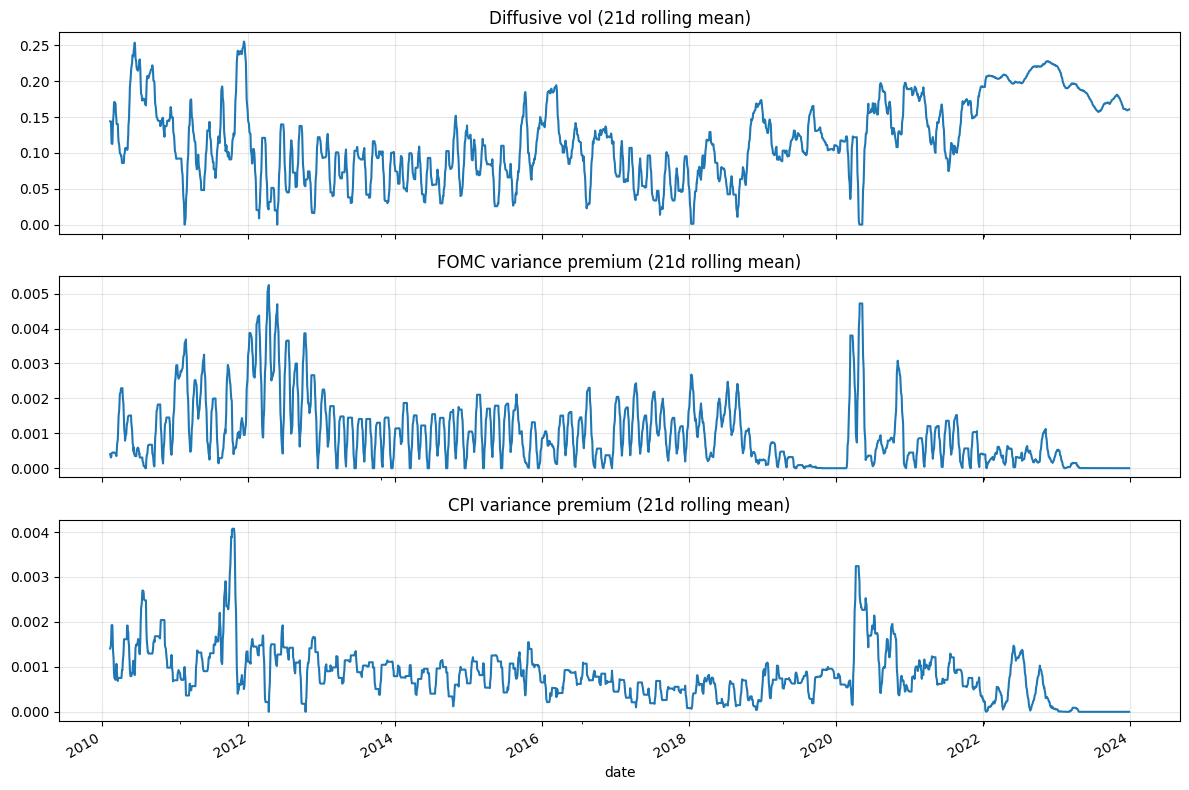

In [18]:
import matplotlib.pyplot as plt
hist = pd.concat([
    pd.read_parquet(p) for p in sorted(XSSVI_HISTORY_DIR.glob('year=*/part.parquet'))
], ignore_index=True)
hist['date'] = pd.to_datetime(hist['date'])

# Aggregate to per-date (decomposition values are date-level, same across rows)
daily = hist.groupby('date').first()[['v_typical_sq','variance_FOMC','variance_CPI']]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
np.sqrt(daily['v_typical_sq']).rolling(21).mean().plot(ax=axes[0], title='Diffusive vol (21d rolling mean)')
daily['variance_FOMC'].rolling(21).mean().plot(ax=axes[1], title='FOMC variance premium (21d rolling mean)')
daily['variance_CPI'].rolling(21).mean().plot(ax=axes[2], title='CPI variance premium (21d rolling mean)')
for ax in axes: ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

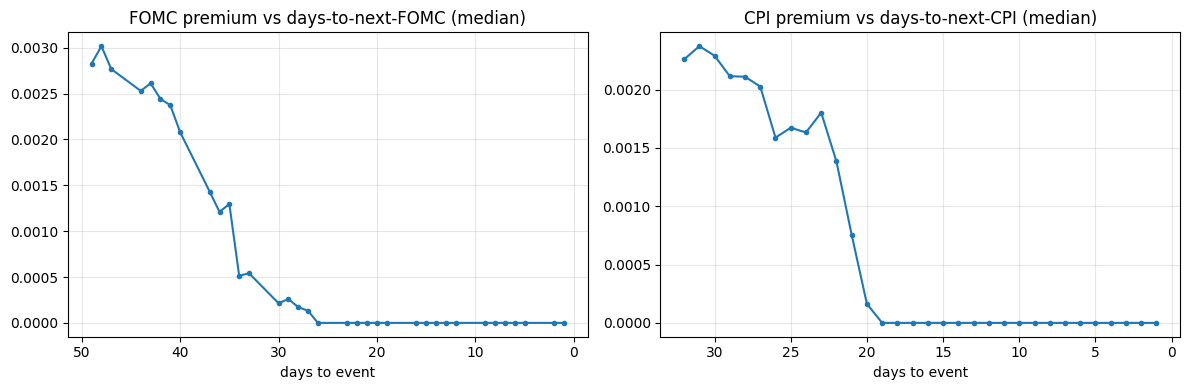

In [19]:
# Event-time alignment: how does FOMC variance behave as we approach the next FOMC?
events_fomc = pd.to_datetime(events[events.event_type=='FOMC'].date.values)
events_cpi  = pd.to_datetime(events[events.event_type=='CPI'].date.values)

def days_to_next(d, event_dates):
    future = event_dates[event_dates > d]
    return int((future.min() - d).days) if len(future) else np.nan

daily = daily.copy()
daily['days_to_FOMC'] = [days_to_next(d, events_fomc) for d in daily.index]
daily['days_to_CPI']  = [days_to_next(d, events_cpi)  for d in daily.index]

agg_f = daily.groupby('days_to_FOMC').variance_FOMC.agg(['mean','median','count'])
agg_c = daily.groupby('days_to_CPI').variance_CPI.agg(['mean','median','count'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
agg_f[agg_f['count']>20].head(45)['median'].plot(ax=axes[0], marker='.', title='FOMC premium vs days-to-next-FOMC (median)')
agg_c[agg_c['count']>20].head(45)['median'].plot(ax=axes[1], marker='.', title='CPI premium vs days-to-next-CPI (median)')
for ax in axes:
    ax.invert_xaxis(); ax.grid(True, alpha=0.3); ax.set_xlabel('days to event')
plt.tight_layout()
plt.show()

                   median      mean       std  count
days_from_event                                     
-10              0.321684  0.345987  0.079694      3
-9               0.137157  0.159089  0.072272     92
-8               0.146384  0.164546  0.071125    112
-7               0.151598  0.166622  0.067178    111
-6               0.148340  0.167126  0.078717    112
-5               0.141410  0.157657  0.076292    107
-4               0.184266  0.272173  0.178713     10
-3               0.238039  0.398212  0.356495      5
-2               0.149190  0.167029  0.076448    103
-1               0.154020  0.169424  0.071925    111
 0               0.143697  0.163113  0.066625    110
 1               0.139872  0.173143  0.112888    112
 2               0.136552  0.159317  0.099651    106
 3               0.213127  0.290307  0.240195      9
 4               0.192909  0.319752  0.315358      5
 5               0.135950  0.165705  0.094758    101
 6               0.141647  0.162920  0.080880 

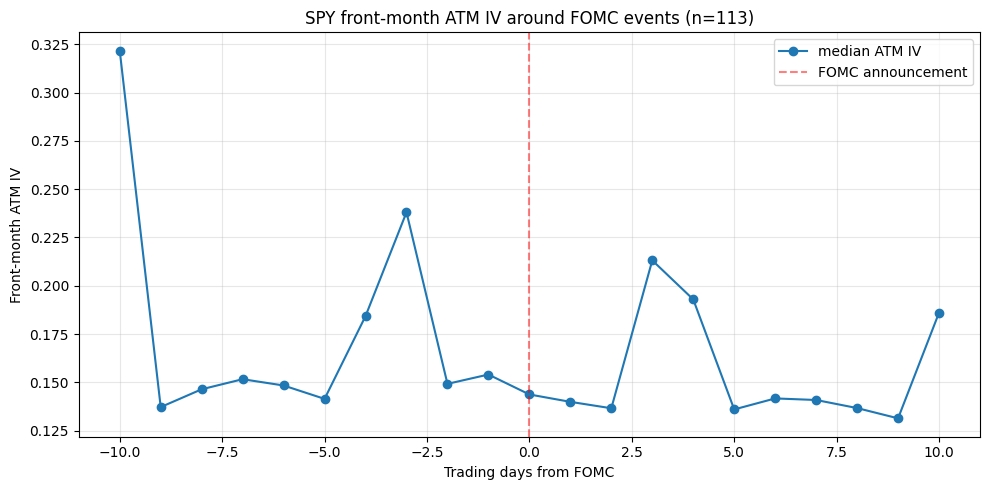

In [20]:
# Event study: SPY ATM IV around FOMC announcements
hist['date'] = pd.to_datetime(hist['date'])
hist['expiry'] = pd.to_datetime(hist['expiry'])

# Front-month ATM IV per date (smallest T per date)
front = hist.sort_values(['date', 'T']).groupby('date').first().reset_index()

# Align to each FOMC event
fomc_dates = pd.to_datetime(events[events.event_type=='FOMC'].date.values)
windows = []
for V in fomc_dates:
    win = front[(front.date >= V - pd.Timedelta(days=10)) &
                (front.date <= V + pd.Timedelta(days=10))].copy()
    win['days_from_event'] = (win.date - V).dt.days
    win['event_id'] = V
    windows.append(win)
study = pd.concat(windows, ignore_index=True)

agg = study.groupby('days_from_event').atm_iv.agg(['median','mean','std','count'])
print(agg)

fig, ax = plt.subplots(figsize=(10, 5))
agg['median'].plot(ax=ax, marker='o', label='median ATM IV')
ax.axvline(0, color='red', linestyle='--', alpha=0.5, label='FOMC announcement')
ax.set_xlabel('Trading days from FOMC'); ax.set_ylabel('Front-month ATM IV')
ax.set_title(f'SPY front-month ATM IV around FOMC events (n={len(fomc_dates)})')
ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout()
plt.show()

Events: 113, mean obs per t: 113


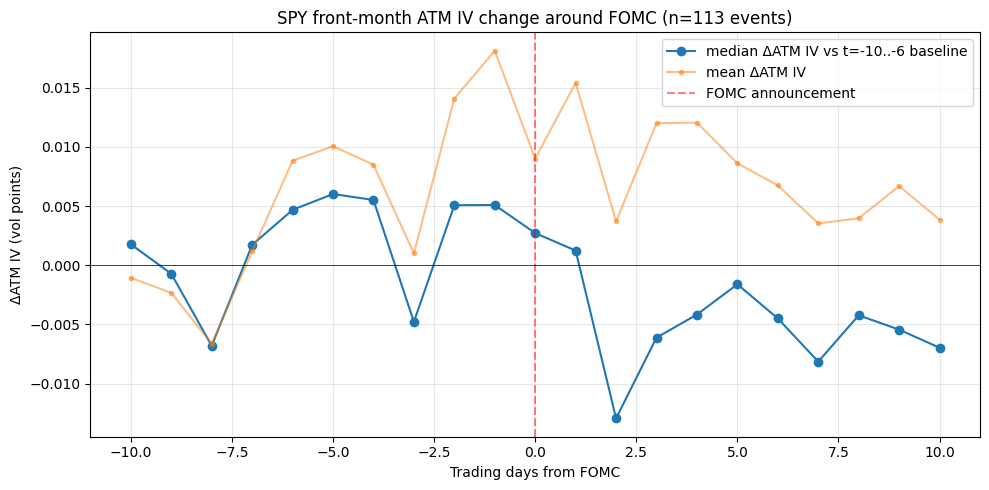

In [21]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

hist['date'] = pd.to_datetime(hist['date'])
front = hist.sort_values(['date', 'T']).groupby('date').first().reset_index()
trading_days = pd.Index(sorted(front.date.unique()))

def td_offset(d, V):
    """Trading-day offset between d and V. Negative = before event."""
    i = trading_days.searchsorted(d)
    j = trading_days.searchsorted(V)
    return i - j

WINDOW = 10  # trading days each side
BASELINE = (-10, -6)  # use t=-10..-6 as the "pre-event normal"

fomc_dates = pd.to_datetime(events[events.event_type=='FOMC'].date.values)

windows = []
for V in fomc_dates:
    # nearest trading day at or before V (handles V landing on a non-trading day)
    V_td = trading_days[trading_days.searchsorted(V, side='right') - 1]
    win = front[(front.date >= V_td - pd.Timedelta(days=20)) &
                (front.date <= V_td + pd.Timedelta(days=20))].copy()
    win['t'] = win.date.apply(lambda d: td_offset(d, V_td))
    win = win[win.t.between(-WINDOW, WINDOW)]
    if win.t.between(*BASELINE).sum() == 0:
        continue
    baseline_iv = win.loc[win.t.between(*BASELINE), 'atm_iv'].mean()
    win['atm_iv_diff'] = win.atm_iv - baseline_iv
    win['event_id'] = V
    windows.append(win)

study = pd.concat(windows, ignore_index=True)
agg = study.groupby('t').atm_iv_diff.agg(['median','mean','count'])
print(f'Events: {len(windows)}, mean obs per t: {agg["count"].mean():.0f}')

fig, ax = plt.subplots(figsize=(10, 5))
agg['median'].plot(ax=ax, marker='o', label='median ΔATM IV vs t=-10..-6 baseline')
agg['mean'].plot(ax=ax, marker='.', alpha=0.5, label='mean ΔATM IV')
ax.axvline(0, color='red', linestyle='--', alpha=0.5, label='FOMC announcement')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Trading days from FOMC'); ax.set_ylabel('ΔATM IV (vol points)')
ax.set_title(f'SPY front-month ATM IV change around FOMC (n={len(windows)} events)')
ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

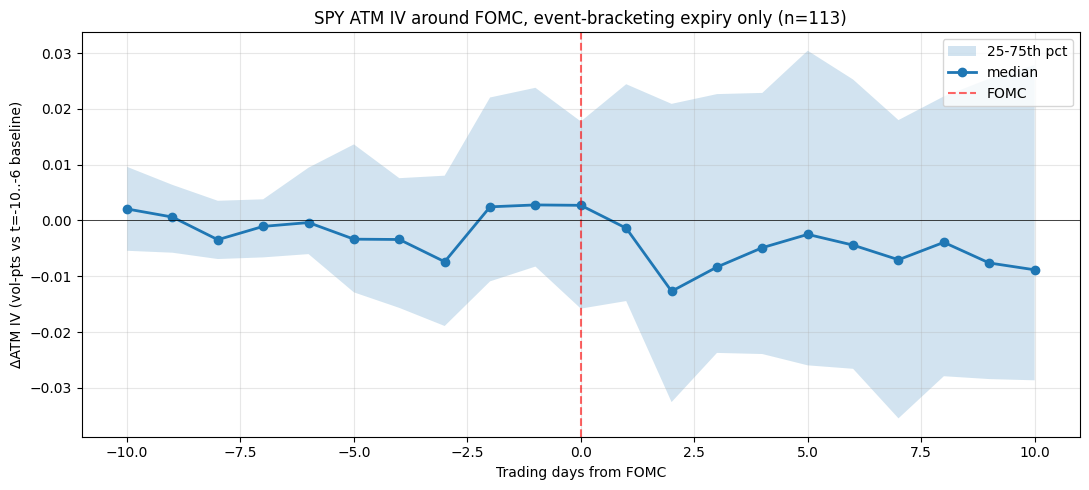

In [22]:
# Pick the expiry that brackets FOMC most tightly: smallest (expiry - V) with expiry >= V
hist['date'] = pd.to_datetime(hist['date'])
hist['expiry'] = pd.to_datetime(hist['expiry'])
trading_days = pd.Index(sorted(hist.date.unique()))

def td_offset(d, V):
    return trading_days.searchsorted(d) - trading_days.searchsorted(V)

WINDOW = 10
BASELINE = (-10, -6)

windows = []
for V in fomc_dates:
    V_td = trading_days[trading_days.searchsorted(V, side='right') - 1]
    win = hist[(hist.date >= V_td - pd.Timedelta(days=21)) &
               (hist.date <= V_td + pd.Timedelta(days=21))].copy()
    # For each date, pick the expiry that brackets V tightly and is at least 3 days out
    win = win[(win.expiry >= V) & ((win.expiry - V).dt.days >= 3)]
    if win.empty: continue
    win['days_expiry_to_V'] = (win.expiry - V).dt.days
    bracket = win.sort_values(['date','days_expiry_to_V']).groupby('date').first().reset_index()
    bracket['t'] = bracket.date.apply(lambda d: td_offset(d, V_td))
    bracket = bracket[bracket.t.between(-WINDOW, WINDOW)]
    if bracket.t.between(*BASELINE).sum() < 3: continue
    baseline_iv = bracket.loc[bracket.t.between(*BASELINE), 'atm_iv'].mean()
    bracket['atm_iv_diff'] = bracket.atm_iv - baseline_iv
    windows.append(bracket[['t','atm_iv_diff']])

study = pd.concat(windows, ignore_index=True)
agg = study.groupby('t').atm_iv_diff.agg(
    p25=lambda s: s.quantile(0.25),
    p50='median',
    p75=lambda s: s.quantile(0.75),
    n='count',
).reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(agg.t, agg.p25, agg.p75, alpha=0.2, label='25-75th pct')
ax.plot(agg.t, agg.p50, marker='o', linewidth=2, label='median')
ax.axvline(0, color='red', linestyle='--', alpha=0.6, label='FOMC')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Trading days from FOMC')
ax.set_ylabel('ΔATM IV (vol-pts vs t=-10..-6 baseline)')
ax.set_title(f'SPY ATM IV around FOMC, event-bracketing expiry only (n={len(windows)})')
ax.grid(True, alpha=0.3); ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

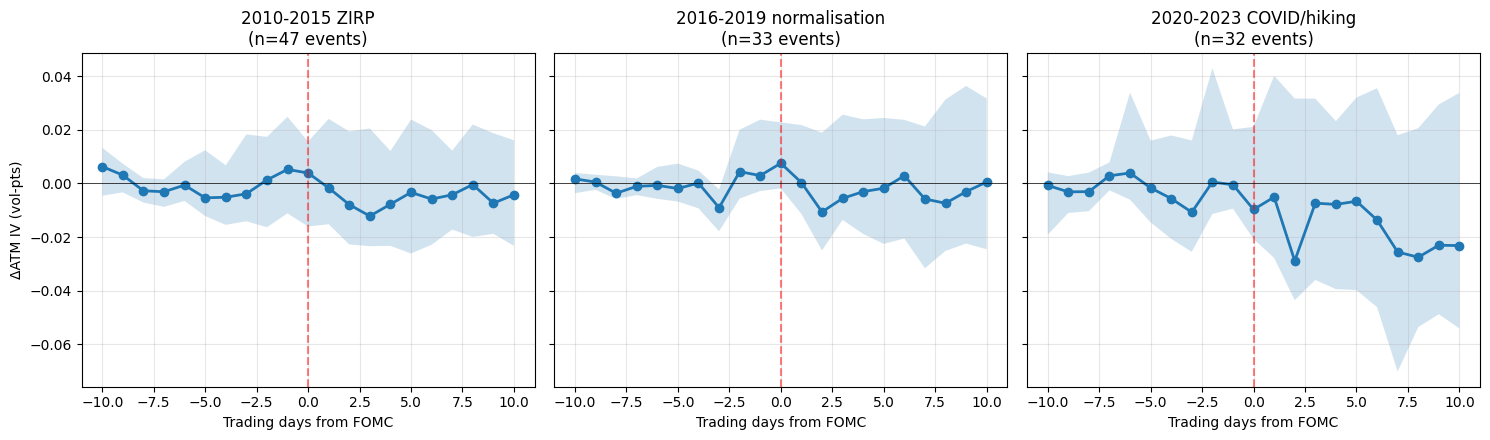

In [23]:
def regime(d):
    if d < pd.Timestamp('2016-01-01'): return '2010-2015 ZIRP'
    if d < pd.Timestamp('2020-03-01'): return '2016-2019 normalisation'
    return '2020-2023 COVID/hiking'

windows_r = []
for V in fomc_dates:
    V_td = trading_days[trading_days.searchsorted(V, side='right') - 1]
    win = hist[(hist.date >= V_td - pd.Timedelta(days=21)) &
               (hist.date <= V_td + pd.Timedelta(days=21))].copy()
    win = win[(win.expiry >= V) & ((win.expiry - V).dt.days >= 3)]
    if win.empty: continue
    win['days_expiry_to_V'] = (win.expiry - V).dt.days
    bracket = win.sort_values(['date','days_expiry_to_V']).groupby('date').first().reset_index()
    bracket['t'] = bracket.date.apply(lambda d: td_offset(d, V_td))
    bracket = bracket[bracket.t.between(-WINDOW, WINDOW)]
    if bracket.t.between(*BASELINE).sum() < 3: continue
    baseline_iv = bracket.loc[bracket.t.between(*BASELINE), 'atm_iv'].mean()
    bracket['atm_iv_diff'] = bracket.atm_iv - baseline_iv
    bracket['regime'] = regime(V)
    windows_r.append(bracket[['t','atm_iv_diff','regime']])

study_r = pd.concat(windows_r, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, reg in zip(axes, ['2010-2015 ZIRP', '2016-2019 normalisation', '2020-2023 COVID/hiking']):
    sub = study_r[study_r.regime == reg]
    n_events = sub.groupby('t').size().iloc[0] if len(sub) else 0
    agg = sub.groupby('t').atm_iv_diff.agg(
        p25=lambda s: s.quantile(0.25),
        p50='median',
        p75=lambda s: s.quantile(0.75),
    ).reset_index()
    ax.fill_between(agg.t, agg.p25, agg.p75, alpha=0.2)
    ax.plot(agg.t, agg.p50, marker='o', linewidth=2)
    ax.axvline(0, color='red', linestyle='--', alpha=0.5)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(f'{reg}\n(n={n_events} events)')
    ax.set_xlabel('Trading days from FOMC')
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('ΔATM IV (vol-pts)')
plt.tight_layout(); plt.show()

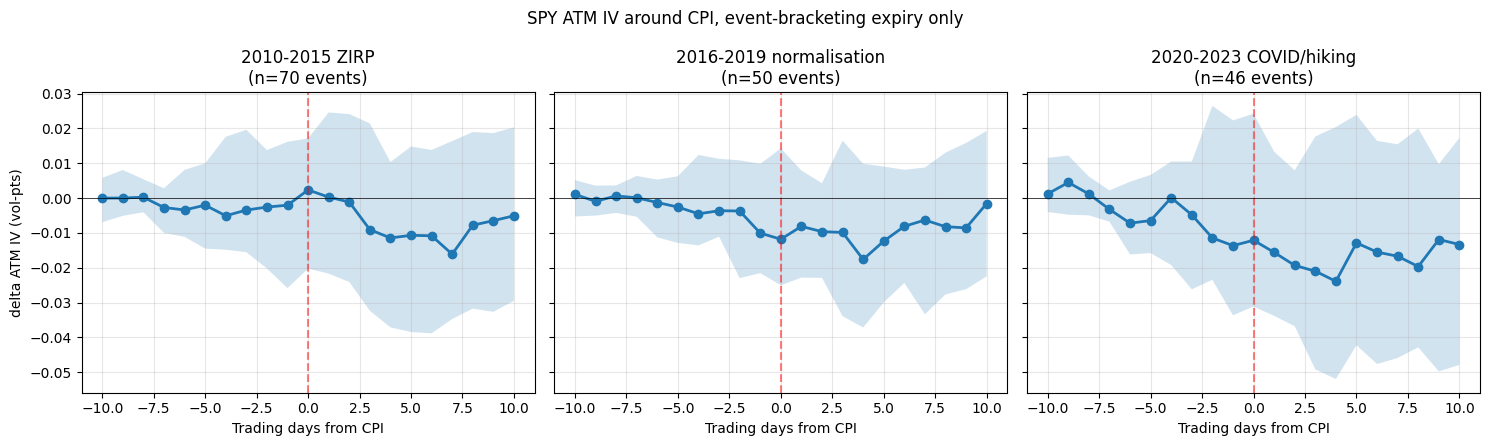

FOMC: median delta-ATM-IV at t=+2 by regime (vol-points)
                 regime  n  median_dIV_vp  p25_vp  p75_vp
         2010-2015 ZIRP 48         -0.788  -2.274  +1.939
2016-2019 normalisation 33         -1.060  -2.497  +1.892
 2020-2023 COVID/hiking 32         -2.884  -4.351  +3.167

CPI: median delta-ATM-IV at t=+2 by regime (vol-points)
                 regime  n  median_dIV_vp  p25_vp  p75_vp
         2010-2015 ZIRP 70         -0.111  -2.408  +2.414
2016-2019 normalisation 50         -0.963  -2.290  +0.429
 2020-2023 COVID/hiking 46         -1.933  -3.680  +0.801

Sample sizes and caveats

FOMC:
  2010-2015 ZIRP: 47 events
  2016-2019 normalisation: 33 events (small - IQR width sensitive to individual events)
  2020-2023 COVID/hiking: 32 events (small - IQR width sensitive to individual events)

CPI:
  2010-2015 ZIRP: 69 events
  2016-2019 normalisation: 50 events
  2020-2023 COVID/hiking: 46 events


In [24]:
# ----------------------------------------------------------------
# 13. Event-study results: regime-stratified analysis
# ----------------------------------------------------------------
# Three additions to the FOMC event study:
#   1. Same regime split applied to CPI events
#   2. Quantification table: median delta-IV at t=+2 by regime and event type
#   3. Sample size caveats printed alongside

import numpy as np, pandas as pd, matplotlib.pyplot as plt

# Load aggregated history if not already in scope
if 'hist' not in dir():
    hist = pd.concat([pd.read_parquet(p) for p in sorted(
        XSSVI_HISTORY_DIR.glob('year=*/part.parquet'))], ignore_index=True)
    hist['date'] = pd.to_datetime(hist['date'])
    hist['expiry'] = pd.to_datetime(hist['expiry'])

trading_days = pd.Index(sorted(hist.date.unique()))

def td_offset(d, V):
    return trading_days.searchsorted(d) - trading_days.searchsorted(V)

def regime(d):
    if d < pd.Timestamp('2016-01-01'): return '2010-2015 ZIRP'
    if d < pd.Timestamp('2020-03-01'): return '2016-2019 normalisation'
    return '2020-2023 COVID/hiking'

WINDOW, BASELINE = 10, (-10, -6)
REGIMES = ['2010-2015 ZIRP', '2016-2019 normalisation', '2020-2023 COVID/hiking']


def build_event_study(event_dates, label):
    windows = []
    for V in event_dates:
        V_td = trading_days[trading_days.searchsorted(V, side='right') - 1]
        win = hist[(hist.date >= V_td - pd.Timedelta(days=21)) &
                   (hist.date <= V_td + pd.Timedelta(days=21))].copy()
        win = win[(win.expiry >= V) & ((win.expiry - V).dt.days >= 3)]
        if win.empty: continue
        win['days_expiry_to_V'] = (win.expiry - V).dt.days
        bracket = win.sort_values(['date','days_expiry_to_V']).groupby('date').first().reset_index()
        bracket['t'] = bracket.date.apply(lambda d: td_offset(d, V_td))
        bracket = bracket[bracket.t.between(-WINDOW, WINDOW)]
        if bracket.t.between(*BASELINE).sum() < 3: continue
        baseline_iv = bracket.loc[bracket.t.between(*BASELINE), 'atm_iv'].mean()
        bracket['atm_iv_diff'] = bracket.atm_iv - baseline_iv
        bracket['regime'] = regime(V)
        bracket['event_type'] = label
        windows.append(bracket[['t','atm_iv_diff','regime','event_type']])
    return pd.concat(windows, ignore_index=True) if windows else pd.DataFrame()


fomc_dates = pd.to_datetime(events[events.event_type == 'FOMC'].date.values)
cpi_dates  = pd.to_datetime(events[events.event_type == 'CPI'].date.values)
study_fomc = build_event_study(fomc_dates, 'FOMC')
study_cpi  = build_event_study(cpi_dates,  'CPI')


# --- CPI regime chart (parallel to the FOMC one) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, reg in zip(axes, REGIMES):
    sub = study_cpi[study_cpi.regime == reg]
    n_events = sub.groupby('t').size().iloc[0] if len(sub) else 0
    agg = sub.groupby('t').atm_iv_diff.agg(
        p25=lambda s: s.quantile(0.25),
        p50='median',
        p75=lambda s: s.quantile(0.75),
    ).reset_index()
    ax.fill_between(agg.t, agg.p25, agg.p75, alpha=0.2)
    ax.plot(agg.t, agg.p50, marker='o', linewidth=2)
    ax.axvline(0, color='red', linestyle='--', alpha=0.5)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(f'{reg}\n(n={n_events} events)')
    ax.set_xlabel('Trading days from CPI')
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('delta ATM IV (vol-pts)')
plt.suptitle('SPY ATM IV around CPI, event-bracketing expiry only')
plt.tight_layout(); plt.show()


# --- Quantification table ---
def summary_at(study, t_target):
    rows = []
    for reg in REGIMES:
        sub = study[(study.regime == reg) & (study.t == t_target)]
        n = len(sub)
        med = float(sub.atm_iv_diff.median()) if n else np.nan
        p25 = float(sub.atm_iv_diff.quantile(0.25)) if n else np.nan
        p75 = float(sub.atm_iv_diff.quantile(0.75)) if n else np.nan
        rows.append({'regime': reg, 'n': n,
                     'median_dIV_vp': med * 100,
                     'p25_vp': p25 * 100, 'p75_vp': p75 * 100})
    return pd.DataFrame(rows)

print('=' * 72)
print('FOMC: median delta-ATM-IV at t=+2 by regime (vol-points)')
print('=' * 72)
print(summary_at(study_fomc, 2).to_string(index=False,
    float_format=lambda x: f'{x:+.3f}' if isinstance(x, float) else str(x)))

print('\n' + '=' * 72)
print('CPI: median delta-ATM-IV at t=+2 by regime (vol-points)')
print('=' * 72)
print(summary_at(study_cpi, 2).to_string(index=False,
    float_format=lambda x: f'{x:+.3f}' if isinstance(x, float) else str(x)))


# --- Sample size caveats ---
print('\n' + '=' * 72)
print('Sample sizes and caveats')
print('=' * 72)
for label, study in [('FOMC', study_fomc), ('CPI', study_cpi)]:
    print(f'\n{label}:')
    counts = study.groupby('regime').event_type.count() // (2 * WINDOW + 1)
    for reg in REGIMES:
        n = int(counts.get(reg, 0))
        note = ''
        if n < 40:
            note = ' (small - IQR width sensitive to individual events)'
        print(f'  {reg}: {n} events{note}')